In [23]:
import importlib
import NeuralNetwork
import funcs

importlib.reload(NeuralNetwork)
importlib.reload(funcs)
from NeuralNetwork import NeuralNetwork

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from collections import defaultdict
import numpy as np
from tqdm.auto import tqdm

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device being used: {device.type}")

device being used: cuda


## Global parameters

In [32]:
# model parameters
HIDDEN_LAYERS = [512, 256, 128, 64]
TRAIN_VAL_SPLIT = 0.8
NUM_WORKERS = 4
 
# initial training
N_TRAIN_EPOCHS = 15 if device.type == "cuda" else 8

# pruning loop
MAX_ALLOWED_ACC_DROP = 0.02
MAX_PRUNE_ROUNDS = 30
PRUNE_FRAC = 0.05
PRUNE_CON_FRAC = 0.1
REGROW_FRAC = 0.1
MIN_VAL_ACC = 0.9
N_RETRIAN_EPOCHS = 3

# clustering
N_CLUSTERS = 10

## Setting up data and initial model

In [12]:
def rotate_image(x):
    return torch.rot90(x, k=-1, dims=[1, 2])

def flip_image(x):
    return torch.flip(x, dims=[2])

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(rotate_image),
    transforms.Lambda(flip_image),
])

# Download and load the training set
train_dataset = datasets.EMNIST(
    root="./data",       # where to store the data
    split="digits",      # "digits" for 0–9, other options: "letters", "balanced", etc.
    train=True,
    download=True,
    transform=transform
)

# Download and load the test set
test_dataset = datasets.EMNIST(
    root="./data",
    split="digits",
    train=False,
    download=True,
    transform=transform
)

In [13]:
train_size = int(TRAIN_VAL_SPLIT * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])
print(f"train size: {train_size}, val size: {val_size}, test size: {len(test_dataset)}")

train size: 192000, val size: 48000, test size: 40000


In [14]:
# Create a DataLoader for batching
batch_size = 4000
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

In [15]:
# Create model and train
model = NeuralNetwork(hidden_sizes=HIDDEN_LAYERS, device=device)
model.train_model(train_loader=train_loader, val_loader=val_loader, epochs=N_TRAIN_EPOCHS)

Training:   0%|          | 0/15 [00:00<?, ?epoch/s]

Epoch 1/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Epoch 2/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Epoch 3/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Epoch 4/15:   0%|          | 0/48 [00:00<?, ?batches/s]

...

Epoch 13/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Epoch 14/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Epoch 15/15:   0%|          | 0/48 [00:00<?, ?batches/s]

Validation:   0%|          | 0/12 [00:00<?, ?batches/s]

Early stopping triggered at epoch 15


## Prune Neurons and Retrain

In [16]:
prune_parameters = (MAX_PRUNE_ROUNDS, PRUNE_FRAC, PRUNE_CON_FRAC, REGROW_FRAC, N_RETRIAN_EPOCHS, MAX_ALLOWED_ACC_DROP)
use_max_rounds = False if device.type == "cuda" else True

final_model, final_val_acc = funcs.pruning(model, train_loader, val_loader, prune_parameters, use_max_rounds=use_max_rounds, mode='full')


--- Pruning round 77 ---


  0%|          | 0/48 [00:00<?, ?it/s]

Retraining after pruning...


Training:   0%|          | 0/3 [00:00<?, ?epoch/s]

Epoch 1/3:   0%|          | 0/48 [00:00<?, ?batches/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?batches/s]

Epoch 3/3:   0%|          | 0/48 [00:00<?, ?batches/s]

Validation:   0%|          | 0/12 [00:00<?, ?batches/s]

Model size unchanged. Converged.


  0%|          | 0/12 [00:00<?, ?it/s]

In [44]:
print(f"Test accuracy after pruning: {final_model.accuracy(train_loader):.2f}")

  0%|          | 0/48 [00:00<?, ?it/s]

Test accuracy after pruning: 0.10


## Activation analysis and Neuron Clustering

In [ ]:
# if os.path.exists("pruned_model.pth"):
#     final_model = torch.load("pruned_model.pth")
#     final_model.eva()
# else:
#     print("No final model saved on disk")

We create a new data loader that does not shuffle the data so our instances match up with our data

In [18]:
analysis_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)

In [19]:
layer_data_analysis = final_model.get_layer_data(analysis_loader)

  0%|          | 0/48 [00:00<?, ?it/s]

In [20]:
for key, value in layer_data_analysis.items():
    print(f"{key} has shape: {value['post_activation'].shape}")

layer_0 has shape: torch.Size([192000, 19])
layer_1 has shape: torch.Size([192000, 19])
layer_2 has shape: torch.Size([192000, 19])
layer_3 has shape: torch.Size([192000, 19])


In [21]:
hidden_layers = [k for k in layer_data_analysis.keys() if 'layer_' in k]

all_neuron_activations = []
for layer_name in hidden_layers:
    acts = layer_data_analysis[layer_name]['post_activation']
    all_neuron_activations.append(acts)

all_neuron_activations = torch.cat(all_neuron_activations, dim=1)

In [22]:
layer_mapping = []
start_idx = 0
for layer_name in hidden_layers:
    n_neurons = layer_data_analysis[layer_name]['post_activation'].shape[1]
    end_idx = start_idx + n_neurons
    layer_mapping.append((layer_name, start_idx, end_idx))
    start_idx = end_idx

In [24]:
labels = []
images = []
for X, y in tqdm(analysis_loader):
    labels.append(y)
    images.append(X)
labels = torch.cat(labels, dim=0)
images = torch.cat(images, dim=0)

  0%|          | 0/48 [00:00<?, ?it/s]

## Clustering

In [ ]:
# from scipy.cluster.hierarchy import linkage, fcluster

# neurons_for_clustering = all_neuron_activations.T.numpy()

# Z = linkage(neurons_for_clustering, method='ward', metric='euclidean')

# n_clusters = N_CLUSTERS
# clusters = fcluster(Z, t=n_clusters, criterion='maxclust')

# print(f"Total neurons clustered: {neurons_for_clustering.shape[0]}")
# print(f"Clusters assigned: {np.unique(clusters)}")

# cluster_map = defaultdict(list)
# for neuron_idx, cluster_id in enumerate(clusters):
#     cluster_map[cluster_id].append(neuron_idx)

In [33]:
from sklearn.decomposition import NMF

n_subsample = 15000
subsample_idx = np.random.choice(all_neuron_activations.shape[0], n_subsample, replace=False)
acts_sub = all_neuron_activations[subsample_idx].numpy()  # [15000, N_neurons]

nmf = NMF(n_components=N_CLUSTERS, random_state=42, max_iter=500)
W = nmf.fit_transform(acts_sub)   # [15000, N_CLUSTERS] — sample loadings
H = nmf.components_               # [N_CLUSTERS, N_neurons] — neuron loadings

# Assign each neuron to the cluster it contributes to most
neuron_assignments = H.argmax(axis=0) + 1  # +1 to match 1-indexed cluster IDs

cluster_map = defaultdict(list)
for neuron_idx, cluster_id in enumerate(neuron_assignments):
    cluster_map[cluster_id].append(neuron_idx)

print(f"Total neurons clustered: {H.shape[1]}")
print(f"Clusters assigned: {np.unique(neuron_assignments)}")

Total neurons clustered: 76
Clusters assigned: [1 2 3 4 5 6 7 8 9]


## Cluster selectivity analysis

In [34]:
selectivity_results = funcs.compute_cluster_selectivity(cluster_map, all_neuron_activations, labels)

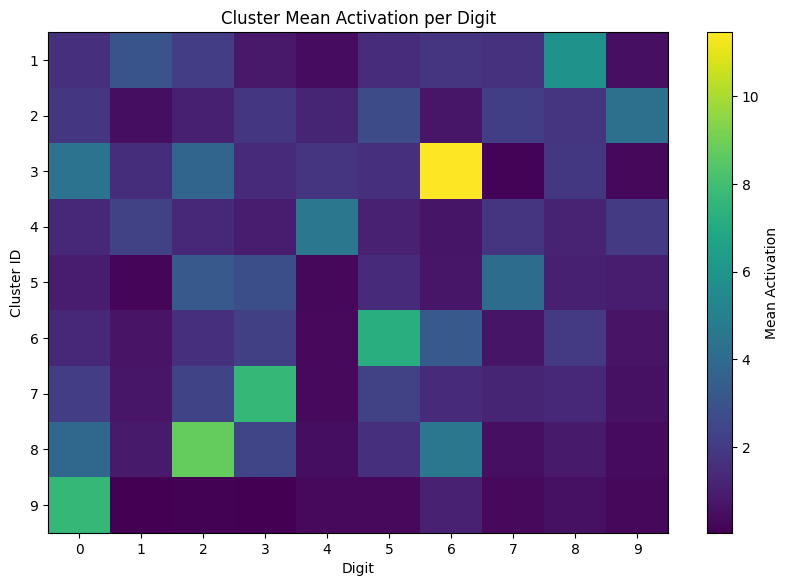

In [35]:
funcs.plot_cluster_activation_heatmap(selectivity_results)

## Cluster ablation

In [36]:
cluster_results = {}
for cluster_id, neuron_indices in cluster_map.items():
    per_class_acc = funcs.cluster_criticality_per_class(
        final_model,
        neuron_indices,
        layer_mapping,
        val_loader,
        cluster_id,
        device=device
    )
    cluster_results[cluster_id] = per_class_acc


--- Calculating pre and post-ablation accuracy for cluster 9 ---


  0%|          | 0/12 [00:00<?, ?it/s]

  0%|          | 0/12 [00:00<?, ?it/s]

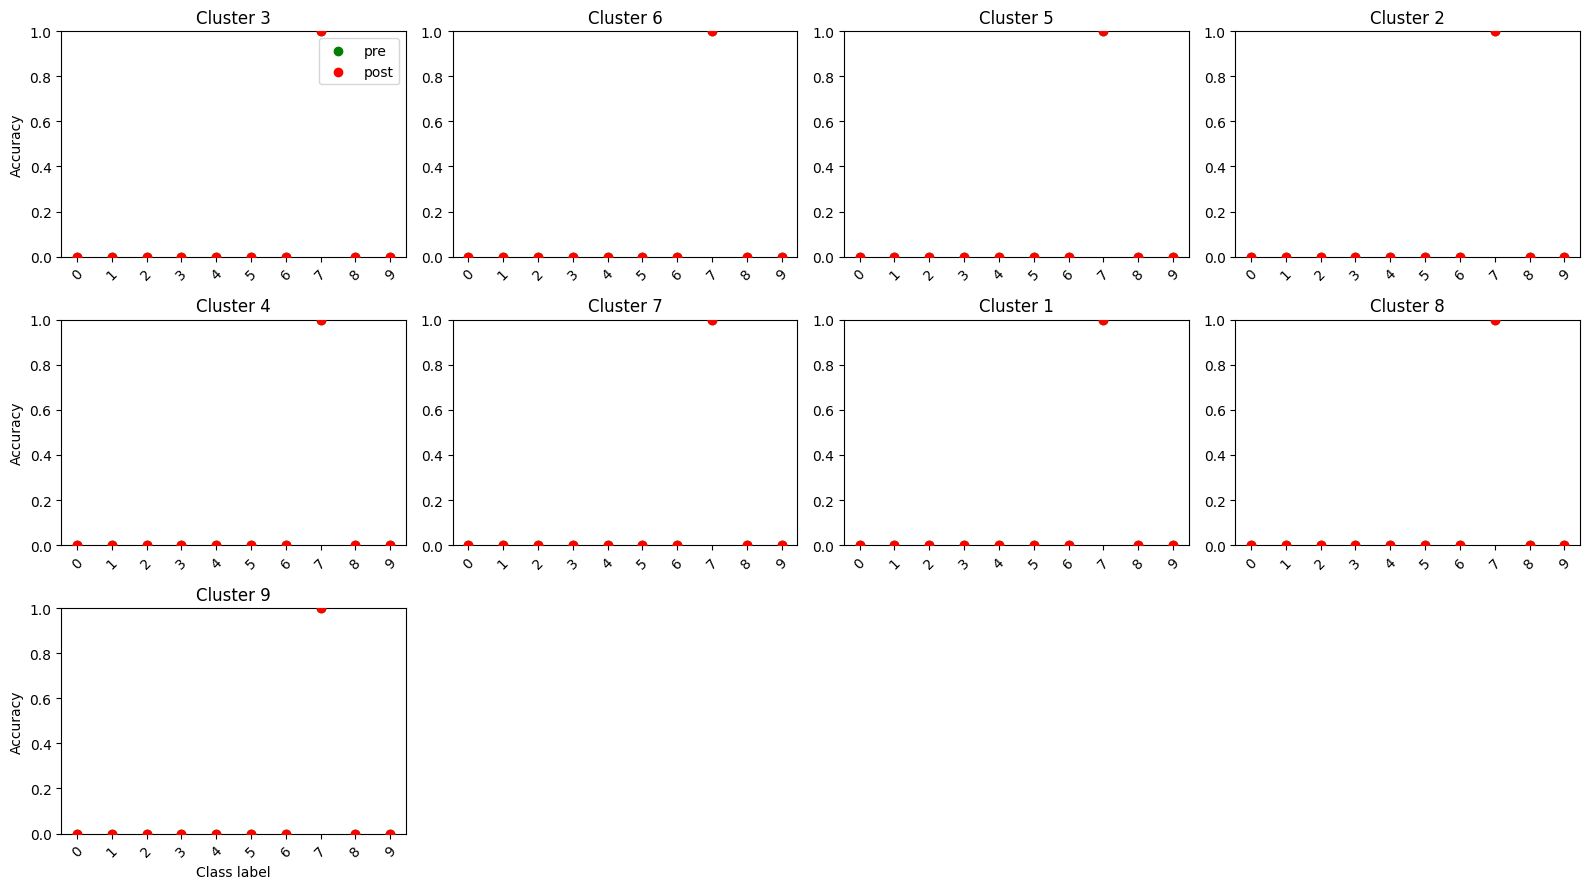

In [37]:
cluster_class_changes = funcs.plot_cluster_accuracy_bars(cluster_results, target_labels=list(range(10)))

## Prototype and difference map plots

In [40]:
# Compute prototypes and difference maps for all clusters
all_prototypes = funcs.compute_prototypes_all_clusters(
    cluster_map=cluster_map,
    all_activations=all_neuron_activations,
    images=images,
    top_frac=0.1,           # fraction of top-activating samples per cluster
    use_global_mean=True     # normalize diff map relative to global mean
)

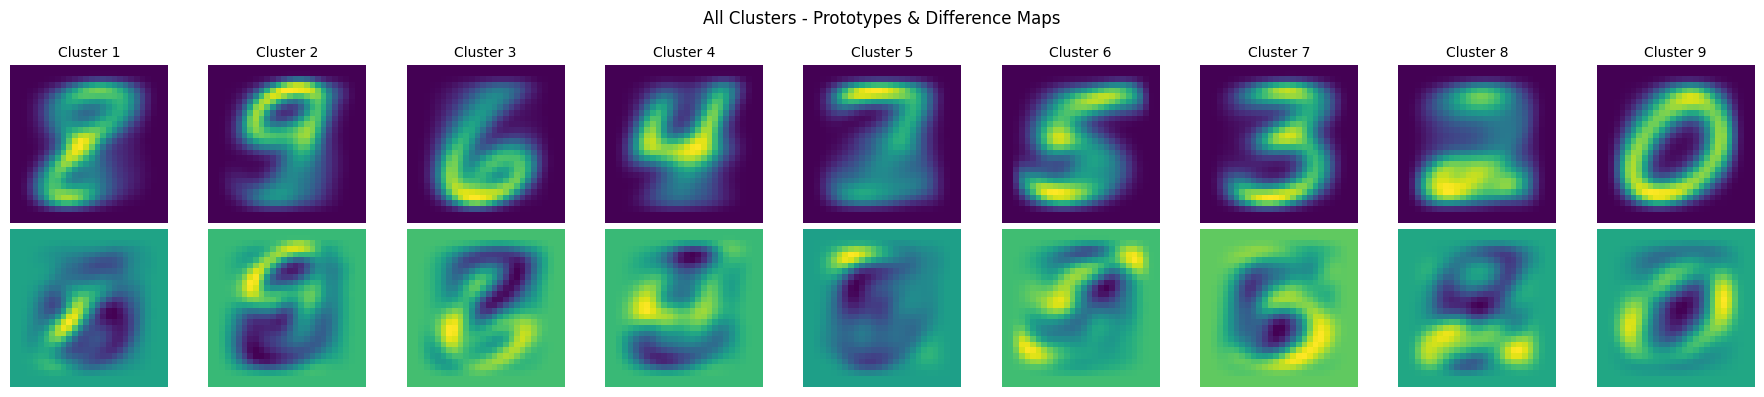

In [41]:
funcs.plot_cluster_prototypes_and_diff_all(all_prototypes)

## cluster extraction